In [ ]:
# Cell 1 — Check GPU
import torch

print("Torch version :", torch.__version__)
print("CUDA available :", torch.cuda.is_available())
print("GPU name       :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Torch version : 2.10.0+cu128
CUDA available : True
GPU name       : Tesla T4


In [ ]:
# Cell 2 — Install dependencies
!pip install ultralytics -q

print("✓ Ultralytics (YOLOv8) installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.6 MB/s eta 0:00:00
✓ Ultralytics (YOLOv8) installed


In [ ]:
# Cell 3 — Imports
from ultralytics import YOLO
import cv2
import torch
import matplotlib.pyplot as plt
from IPython.display import display, Image
import numpy as np

print("✓ All libraries imported")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ All libraries imported


In [ ]:
# Cell 4 — Load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")  # downloads ~6MB automatically

print("✓ Model loaded")
print(f"  Running on : {torch.cuda.get_device_name(0)}")

✓ Model loaded
  Running on : Tesla T4


In [ ]:
# Cell 5 — Target classes (COCO IDs relevant to our project)

TARGET_CLASSES = {
    0  : "person",
    9  : "traffic light",
    11 : "stop sign",
    2  : "car",
    7  : "truck",
}

# Bounding box colors (RGB for matplotlib)
CLASS_COLORS = {
    0  : (255, 200, 0),    # person       → yellow
    9  : (0,   255, 100),  # traffic light → green
    11 : (255, 50,  50),   # stop sign    → red
    2  : (150, 150, 150),  # car          → gray
    7  : (100, 100, 100),  # truck        → dark gray
}

print("✓ Target classes defined:")
for id, name in TARGET_CLASSES.items():
    print(f"   Class {id:2d} → {name}")

✓ Target classes defined:
   Class  0 → person
   Class  9 → traffic light
   Class 11 → stop sign
   Class  2 → car
   Class  7 → truck


In [ ]:
# Cell 6 — Core detector function (your main contribution)

def detect(frame, conf_threshold=0.45):
    """
    Run YOLOv8 on a single frame.

    Args:
        frame          : BGR image (numpy array from OpenCV)
        conf_threshold : minimum confidence to keep a detection

    Returns:
        detections : list of dicts [{class_id, class_name, confidence, bbox}]
        annotated  : frame with bounding boxes drawn
    """
    results = model.predict(
        source=frame,
        conf=conf_threshold,
        device="cuda" if torch.cuda.is_available() else "cpu",
        verbose=False,
    )

    detections = []
    annotated = frame.copy()

    for result in results:
        for box in result.boxes:
            class_id = int(box.cls[0])

            # Keep only our target classes
            if class_id not in TARGET_CLASSES:
                continue

            confidence = float(box.conf[0])
            class_name = TARGET_CLASSES[class_id]
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            detections.append({
                "class_id"   : class_id,
                "class_name" : class_name,
                "confidence" : confidence,
                "bbox"       : (x1, y1, x2, y2),
            })

            # Draw bounding box
            color = CLASS_COLORS.get(class_id, (255, 255, 255))
            color_bgr = (color[2], color[1], color[0])  # convert to BGR for OpenCV
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color_bgr, 2)

            label = f"{class_name} {confidence:.2f}"
            (lw, lh), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
            cv2.rectangle(annotated, (x1, y1 - lh - 8), (x1 + lw + 4, y1), color_bgr, -1)
            cv2.putText(annotated, label, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 1)

    return detections, annotated


def show_frame(frame, title="Detection result"):
    """Helper to display a BGR frame nicely inside Colab."""
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 7))
    plt.imshow(rgb)
    plt.title(title, fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

print("✓ detect() function ready")

✓ detect() function ready


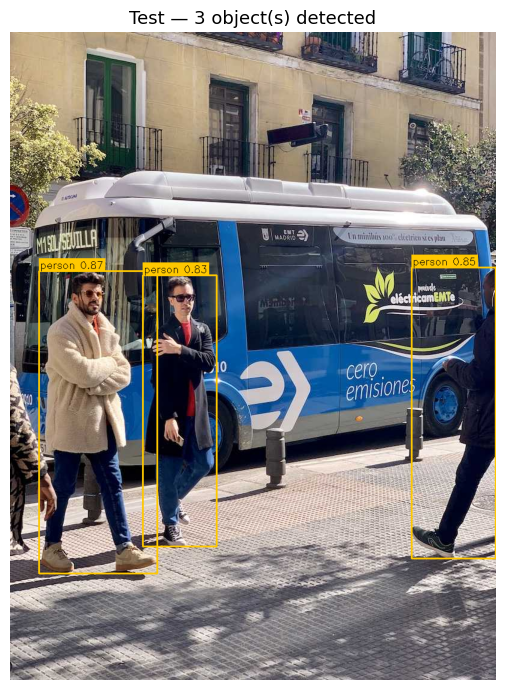


3 detection(s):
  person          | conf: 0.87 | bbox: (48, 398, 245, 902)
  person          | conf: 0.85 | bbox: (669, 392, 809, 877)
  person          | conf: 0.83 | bbox: (221, 405, 344, 857)


In [ ]:
# Cell 7 — Quick test on a sample image (no video needed yet)

import urllib.request

# Download a free street scene image for testing
url = "https://ultralytics.com/images/bus.jpg"
urllib.request.urlretrieve(url, "test_image.jpg")

# Load and run detection
frame = cv2.imread("test_image.jpg")
detections, annotated = detect(frame)

# Show result
show_frame(annotated, title=f"Test — {len(detections)} object(s) detected")

# Print detections
print(f"\n{len(detections)} detection(s):")
for d in detections:
    print(f"  {d['class_name']:15s} | conf: {d['confidence']:.2f} | bbox: {d['bbox']}")

In [ ]:
# Cell 8 — Run detection on a video file
# Upload any traffic video first using the Colab file panel (left sidebar → upload)

import time

VIDEO_PATH = "Video.mp4"   # ← change this to your uploaded video name
OUTPUT_PATH = "output.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)

width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps_in = cap.get(cv2.CAP_PROP_FPS)

out = cv2.VideoWriter(OUTPUT_PATH,
                      cv2.VideoWriter_fourcc(*"mp4v"),
                      fps_in, (width, height))

frame_count = 0
start_time  = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    detections, annotated = detect(frame)

    # FPS overlay
    elapsed = time.time() - start_time
    fps_live = frame_count / (elapsed + 1e-6)
    cv2.putText(annotated, f"FPS: {fps_live:.1f}", (10, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 200), 2)

    out.write(annotated)
    frame_count += 1

    if frame_count % 30 == 0:
        print(f"  Processed {frame_count} frames | FPS: {fps_live:.1f}")

cap.release()
out.release()

total_time = time.time() - start_time
print(f"\n✓ Done — {frame_count} frames in {total_time:.1f}s")
print(f"  Average FPS : {frame_count/total_time:.1f}")
print(f"  Output saved: {OUTPUT_PATH}")

  Processed 30 frames | FPS: 41.3
  Processed 60 frames | FPS: 40.1
  Processed 90 frames | FPS: 42.3
  Processed 120 frames | FPS: 43.8
  Processed 150 frames | FPS: 44.8
  Processed 180 frames | FPS: 45.5
  Processed 210 frames | FPS: 46.2
  Processed 240 frames | FPS: 46.5
  Processed 270 frames | FPS: 47.0
  Processed 300 frames | FPS: 47.2
  Processed 330 frames | FPS: 47.6
  Processed 360 frames | FPS: 47.8
  Processed 390 frames | FPS: 48.0
  Processed 420 frames | FPS: 48.4
  Processed 450 frames | FPS: 47.3
  Processed 480 frames | FPS: 46.5
  Processed 510 frames | FPS: 45.7
  Processed 540 frames | FPS: 45.4
  Processed 570 frames | FPS: 45.7
  Processed 600 frames | FPS: 45.9
  Processed 630 frames | FPS: 46.1
  Processed 660 frames | FPS: 46.3
  Processed 690 frames | FPS: 46.5
  Processed 720 frames | FPS: 46.8
  Processed 750 frames | FPS: 47.1

✓ Done — 750 frames in 15.9s
  Average FPS : 47.2
  Output saved: output.mp4


In [ ]:
# Cell 9 — Play the output video inside Colab

from IPython.display import HTML
from base64 import b64encode

mp4 = open("output.mp4", "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width="800" controls autoplay loop>
  <source src="{data_url}" type="video/mp4">
</video>
""")